In [26]:
# 관련 모듈과 라이브러리 import하기

# nn: 신경망 만들 때 쓰는 기본 도구들 (레이어, 활성화 함수 등)
import torch.nn as nn

# torch: 텐서 다루고 GPU 쓸 수 있게 해준다
import torch 

import torchvision.models as models

# datasets: 유명한 데이터셋 쉽게 다운받게 해줌
from torchvision import datasets

# transforms: 이미지를 모델이 먹을 수 있게 변환해줌(텐서로 변환하고 정규화)
from torchvision import transforms

# DataLoader: 데이터를 불러오는 애
from torch.utils.data import DataLoader

# numpy: 숫자 계산할 때 쓰는 라이브러리
import numpy as np

# optim: 모델을 학습시키는 최적화 알고리즘들 (경사하강법 등)
import torch.optim as optim 

# plt: 그래프 그리고 이미지 보여주는 애
import matplotlib.pyplot as plt

# 모듈 재로딩 (models.py 변경사항 적용)
import importlib
import models
importlib.reload(models)

# 모델 불러오기 (models.py에서 모든 모델 import)
from models import CNN, ResNet18_CIFAR, ResNet50_CIFAR, VGG16_CIFAR, MobileNetV2_CIFAR

# 공격 기법 불러오기 - 모듈 재로딩
import attacks
importlib.reload(attacks)
from attacks import fgsm_attack, ifgsm_attack, pgd_attack

In [27]:
# gpu 사용 위해 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [28]:
# RobustBench에서 Robust 모델 불러오기 옵션
from robustbench.utils import load_model

# 사용 가능한 robust 모델들:
# 'Wong2020Fast' - 빠른 adversarial training
# 'Carmon2019Unlabeled' - unlabeled data 활용
# 'Sehwag2020Hydra' - Hydra 모델
# 'Rebuffi2021Fixing_70_16_cutmix_extra' - SOTA 모델
# 'Ding2020MMA' - MMA 모델

# CIFAR-10용 robust 모델 (예시)
# robust_model = load_model(model_name='Wong2020Fast', dataset='cifar10', threat_model='Linf')
# robust_model = robust_model.to(device)
# print("Robust 모델 로드 완료: Wong2020Fast")

In [29]:
# 모델 선택
MODEL_TYPE = 'Wong2020Fast'  # 'Wong2020Fast', 'Ding2020MMA', 'Carmon2019Unlabeled', 'Resnet50_CIFAR'
if MODEL_TYPE == 'Resnet50_CIFAR':
    # 자신이 학습한 Resnet50_CIFAR 모델
    model = ResNet50_CIFAR(num_classes=10)
    model.load_state_dict(torch.load('cifar10_cnn_model.pth'))
    print('내 CIFAR-10 모델')

elif MODEL_TYPE == 'CNN':
    # 자신이 학습한 CNN 모델
    model = CNN()
    model.load_state_dict(torch.load('cifar10_cnn_model.pth'))
    print('내 CNN 모델')

elif MODEL_TYPE == 'Resnet18_CIFAR':
    # 자신이 학습한 ResNet18 모델
    model = ResNet18_CIFAR()
    model.load_state_dict(torch.load('cifar10_cnn_model.pth'))
    print('내 ResNet18 모델')

elif MODEL_TYPE == 'VGG16_CIFAR':
    # 자신이 학습한 VGG16 모델
    model = VGG16_CIFAR()
    model.load_state_dict(torch.load('cifar10_cnn_model.pth'))
    print('내 VGG16 모델')

elif MODEL_TYPE == 'Wong2020Fast':
    # RobustBench의 Wong2020Fast robust 모델 (CIFAR-10)
    from robustbench.utils import load_model
    model = load_model(model_name='Wong2020Fast', dataset='cifar10', threat_model='Linf')
    print('RobustBench Wong2020Fast 모델')

elif MODEL_TYPE == 'Carmon2019Unlabeled':
    # RobustBench의 Carmon2019Unlabeled robust 모델 (CIFAR-10)
    from robustbench.utils import load_model
    model = load_model(model_name='Carmon2019Unlabeled', dataset='cifar10', threat_model='Linf')
    print('RobustBench Carmon2019Unlabeled 모델')

elif MODEL_TYPE == 'Ding2020MMA':
    # RobustBench의 Ding2020MMA robust 모델 (CIFAR-10)
    from robustbench.utils import load_model
    model = load_model(model_name='Ding2020MMA', dataset='cifar10', threat_model='Linf')
    print('RobustBench Ding2020MMA 모델')

model.to(device)
# 평가 모드로 전환
model.eval()
print(f'사용 모델: {MODEL_TYPE}')

RobustBench Wong2020Fast 모델
사용 모델: Wong2020Fast


/usr/local/lib/python3.12/dist-packages/robustbench/utils.py:165: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=torch.device

In [30]:
# 테스트 데이터셋 불러오자.

# 데이터셋 저장 경로
download_root = 'CIFAR10_data/'
#정규화 
transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# 테스트용 데이터셋
dataset2 = datasets.CIFAR10(root=download_root,
                            # 학습용이 아니므로 이번에는 False!
                            train = False, 
                            transform = transformations,
                            download=True)

Files already downloaded and verified


In [31]:
# 공격 대상 데이터로더 만들기
test_loader = DataLoader(dataset2,
                        batch_size=100,
                        shuffle=False)

# CIFAR-10 클래스 이름들 (10개)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

In [32]:
# # 이미지 한 배치 가져오기
# for images, labels in test_loader:
#     # 배치에서 이미지와 레이블 가져오기
#     images, labels = images.to(device), labels.to(device)
#     # 원본 이미지로 모델 예측해보기
#     break # 첫 번째 배치만 사용하기 위해 루프 종료 -> 이미지 64장과 레이블 64개만 있음

In [33]:
# i = iter(test_loader)
# print(next(i)[0][0].shape)

In [34]:
# print(images)
# print(labels[0].shape)

In [35]:
# 공격 적용 (전체 테스트셋) - 배치 처리 버전 (훨씬 빠름!)
epsilon = 0.1  # 공격 강도 설정
attack_success = 0
attack_fail = 0
success_cases = []
fail_cases = []

# 전체 테스트셋 순회
for batch_idx, (images, labels) in enumerate(test_loader):
    # 배치를 GPU로 이동
    images, labels = images.to(device), labels.to(device)
    
    # 배치 전체에 대해 gradient 계산
    images.requires_grad = True
    
    # 배치 전체 forward
    outputs = model(images)
    loss_function = nn.CrossEntropyLoss()
    
    # 배치 전체에 대해 한 번에 loss 계산 및 backward
    loss = loss_function(outputs, labels)
    loss.backward()
    
    data_grad = images.grad.data
    
    # 배치 전체 공격 수행
    adv_images = pgd_attack(model, images, labels, epsilon, iters=10)
    
    # 배치 전체 예측
    with torch.no_grad():
        adv_outputs = model(adv_images)
        _, predicted = torch.max(adv_outputs, 1)
    
    # 결과 집계
    for i in range(len(labels)):
        true_label = labels[i].item()
        pred_label = predicted[i].item()
        
        if pred_label == true_label:
            attack_fail += 1
            if len(fail_cases) < 5:
                fail_cases.append((images[i].detach().cpu(), adv_images[i].detach().cpu(),
                                 classes[true_label], classes[pred_label]))
        else:
            attack_success += 1
            if len(success_cases) < 5:
                success_cases.append((images[i].detach().cpu(), adv_images[i].detach().cpu(),
                                    classes[true_label], classes[pred_label]))
    
    # 진행 상황 출력 (매 10 배치마다)
    if (batch_idx + 1) % 10 == 0:
        total = attack_success + attack_fail
        print(f'Progress: {total}/10000 images, ASR: {attack_success/total*100:.2f}%')

print("\n=== 공격 결과 요약 ===")
print(f'Attack Success Rate: {attack_success / (attack_success + attack_fail) * 100:.2f}%')

Progress: 1000/10000 images, ASR: 86.90%
Progress: 2000/10000 images, ASR: 85.70%
Progress: 3000/10000 images, ASR: 85.77%
Progress: 4000/10000 images, ASR: 85.25%
Progress: 5000/10000 images, ASR: 84.62%
Progress: 6000/10000 images, ASR: 84.82%
Progress: 7000/10000 images, ASR: 84.87%
Progress: 8000/10000 images, ASR: 85.15%
Progress: 9000/10000 images, ASR: 85.12%
Progress: 10000/10000 images, ASR: 85.01%

=== 공격 결과 요약 ===
Attack Success Rate: 85.01%


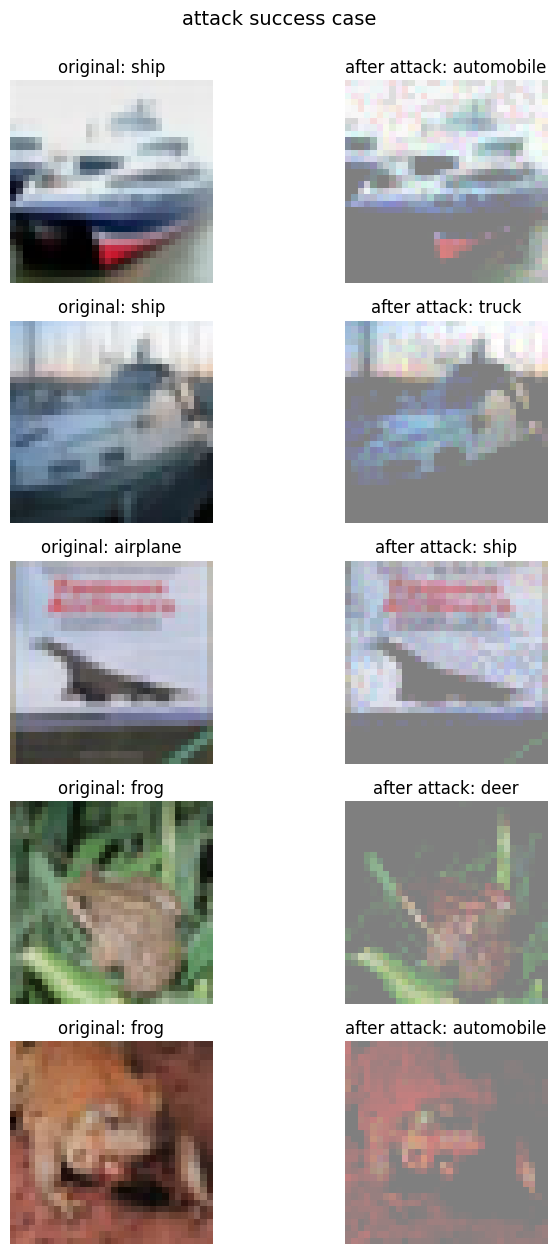

In [36]:
# 이미지를 denormalize하는 함수
def denormalize(img):
    """정규화된 이미지를 원래대로 되돌림"""
    img = img * 0.5 + 0.5  # [-1, 1] → [0, 1]
    return img

# 공격 성공 케이스 시각화
if len(success_cases) > 0:
    fig, axes = plt.subplots(len(success_cases), 2, figsize=(8, 2.5*len(success_cases)))
    if len(success_cases) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (orig_img, adv_img, true_cls, pred_cls) in enumerate(success_cases):
        # 원본 이미지
        orig_np = denormalize(orig_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(orig_np)
        axes[i, 0].set_title(f'original: {true_cls}')
        axes[i, 0].axis('off')
        
        # 공격된 이미지
        adv_np = denormalize(adv_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 1].imshow(adv_np)
        axes[i, 1].set_title(f'after attack: {pred_cls}')
        axes[i, 1].axis('off')
    
    plt.suptitle('attack success case', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()


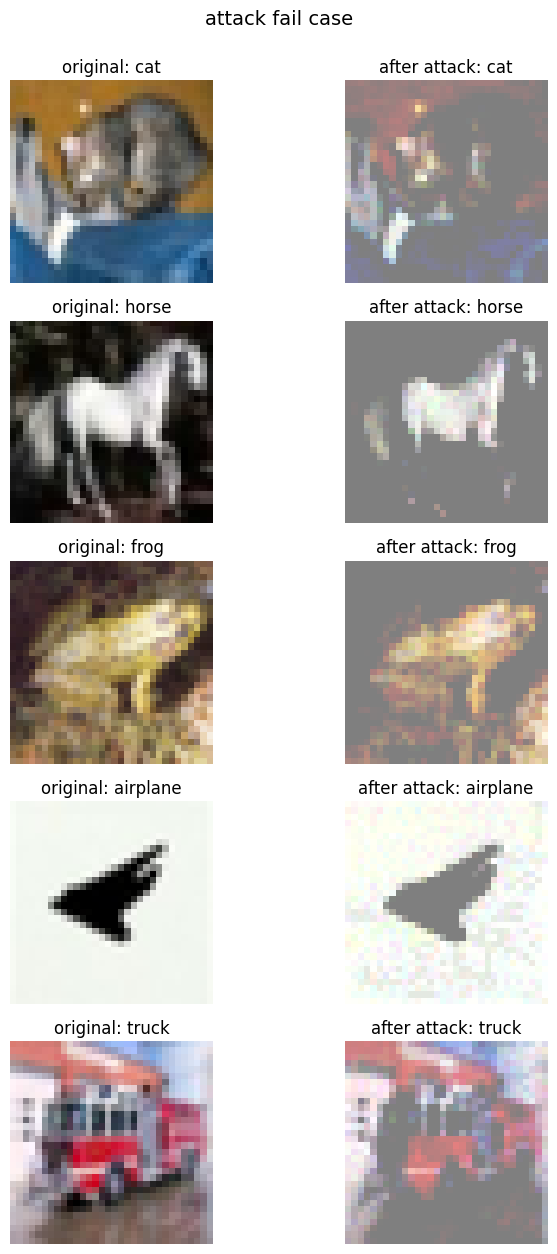

In [37]:
# 공격 실패 케이스 시각화
if len(fail_cases) > 0:
    fig, axes = plt.subplots(len(fail_cases), 2, figsize=(8, 2.5*len(fail_cases)))
    if len(fail_cases) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (orig_img, adv_img, true_cls, pred_cls) in enumerate(fail_cases):
        # 원본 이미지
        orig_np = denormalize(orig_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 0].imshow(orig_np)
        axes[i, 0].set_title(f'original: {true_cls}')
        axes[i, 0].axis('off')
        
        # 공격된 이미지
        adv_np = denormalize(adv_img).squeeze().permute(1, 2, 0).numpy()
        axes[i, 1].imshow(adv_np)
        axes[i, 1].set_title(f'after attack: {pred_cls}')
        axes[i, 1].axis('off')
    
    plt.suptitle('attack fail case', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()
